In [24]:
import matplotlib.pyplot as plt

from brian2 import *
import scienceplots

In [25]:
DARK_BLUE  = (0.0, 0.4667, 0.7333)
LIGHT_BLUE = (0.2, 0.7333, 0.9333)
GREEN      = (0.0, 0.6, 0.5333)
ORANGE     = (0.9333, 0.4667, 0.2)
RED        = (0.8, 0.2, 0.0667)
PINK       = (0.9333, 0.2, 0.4667)
GRAY       = (0.7333, 0.7333, 0.7333)

SAVE = True

In [26]:
seed(0)

In [27]:
# ----------------------- Models -----------------------
# --- Brian Equations ---
eqs_neurons = '''
r = clip(u, 0 * Hz, 100 * Hz) : Hz
dr_slow/dt = 1 / Tau_slow * (-r_slow + r**2) : Hz*Hz
du/dt = 1 / Tau * (-u + u_syn + u_r + r_ext) : Hz
du_r/dt = - Theta_ur * (u_r - U_r0) + (Sigma_ur * xi)*Hz : Hz
r_ext : Hz
u_syn : Hz
sum_w : 1
X : metre (constant)
Y : metre (constant)
U_r0 : Hz (constant)
Theta_ur : Hz (constant)
Sigma_ur : Hz**0.5 (constant)
Tau : second (constant)
Tau_slow : second (constant)
'''

eqs_syn = '''
dw = r_pre/Hz * r_post/Hz * (r_post - theta) : Hz (constant over dt)
ddelta_w/dt = 1 / Tau_W * (dw - delta_w) : Hz (clock-driven)
dw/dt = Lr * clip(
    delta_w * (int(delta_w < 0*Hz) * int(w > 0.01) + int(delta_w > 0*Hz) * int(w < 0.5)), 
    -30*17*Hz, 30*17*Hz)
    # - 1 / C * int(sum_w_pre > W_sum_max * DEG) * int(w > 0.01) * (sum_w_pre - W_sum_max * DEG)
: 1 (clock-driven)
theta = r_slow_post / R_0 : Hz (constant over dt)
u_syn_post = w * r_pre : Hz (summed)
sum_w_pre = w : 1 (summed)
Lr : 1 (constant)
W_sum_max : 1 (constant)
R_0 : Hz (constant)
C : second (constant)
Tau_W : second (constant)
DEG : 1 (constant)
'''

In [28]:
DT_RECORD = 1*ms
LR = 1e-4

In [29]:
def init_network(w_init, n_inputs, t_init):
    all_neurons = NeuronGroup(n_inputs + 1, eqs_neurons, method='euler')
    input_neurons = all_neurons[:n_inputs]
    output_neuron = all_neurons[n_inputs]
    synapses = Synapses(input_neurons, output_neuron, eqs_syn, method='euler')
    synapses.connect()
    
    all_neurons.Tau_slow = 1000*ms
    all_neurons.Tau = 10*ms
    all_neurons.u = 2*Hz
    all_neurons.Theta_ur = 1*Hz
    
    input_neurons.U_r0 = 2*Hz
    output_neuron.U_r0 = 1*Hz
    
    synapses.R_0 = 2*Hz
    synapses.w = f'0.05*rand()'
    synapses.w[0] = w_init
    synapses.w[1:] = synapses.w[1:] / sum(synapses.w[1:]) * (0.5-w_init)
    synapses.Lr = LR
    synapses.Lr[0] = 0.
    synapses.Tau_W = 100*ms
    synapses.W_sum_max = 1.2
    synapses.C = 2_000*ms
    
    M = StateMonitor(all_neurons, ['r', 'r_slow'], record=True, dt=DT_RECORD)
    S = StateMonitor(synapses, ['w', 'theta', 'dw', 'delta_w'], record=True, dt=DT_RECORD)
    
    net = Network(synapses, all_neurons, M, S)
    
    net.run(t_init)
    net.store("init_5_min")
    
    return net, input_neurons, output_neuron, synapses, M, S

def random_stimulation(network, tau_slow, restore=True, store=True):
    if restore:
        network["net"].restore("init_5_min")
    network["output_neuron"].Tau_slow = tau_slow
    network["synapses"].Lr[0] = LR
    network["input_neurons"][0:1].r_ext = 5*Hz
    network["net"].run(4*second)
    network["input_neurons"][0:1].r_ext = 0*Hz
    network["net"].run(5*second)
    if store:
        network["net"].store(f"post_random_{tau_slow/second:.2f}")
    return network["synapses"].w[0]
    
def sync_stimulation(network, tau_slow, t_after=5*second, restore=True, store=True):
    if restore:
        network["net"].restore("init_5_min")
    network["output_neuron"].Tau_slow = tau_slow
    network["synapses"].Lr[0] = LR
    network["input_neurons"][0:1].r_ext = 30*Hz
    network["net"].run(0.1*second)
    network["input_neurons"][0:1].r_ext = 0*Hz
    network["net"].run(t_after)
    network["net"].store(f"post_sync_{tau_slow/second:.2f}")
    return network["synapses"].w[0]

def gameplay_stimulation(network, tau_slow, t_stim=0.2*second, t_after=5*second, restore=True, store=True):
    if restore:
        network["net"].restore("init_5_min")
    network["output_neuron"].Tau_slow = tau_slow
    network["synapses"].Lr[0] = LR
    network["input_neurons"][0:1].r_ext = 7*Hz
    network["net"].run(t_stim)
    network["input_neurons"][0:1].r_ext = 0*Hz
    network["net"].run(t_after)
    if store:
        network["net"].store(f"post_gameplay_{tau_slow/second:.2f}")
    return network["synapses"].w[0]

In [30]:
w_grid = np.array([0.1]) #0.1, 0.15, 0.2, 0.25, 
networks = []
for w_stim in w_grid:
    net, input_neurons, output_neuron, synapses, M, S = init_network(w_stim, 10, 300*second)
    _dict = {"input_neurons" : input_neurons,
             "output_neuron" : output_neuron,
             "synapses" : synapses,
             "net" : net,
             "M" : M,
             "S" : S,
             "w_stim": w_stim
             }
    networks.append(_dict)

WARNING    'w' is an internal variable of group 'synapses_1', but also exists in the run namespace with the value np.float64(6.12). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


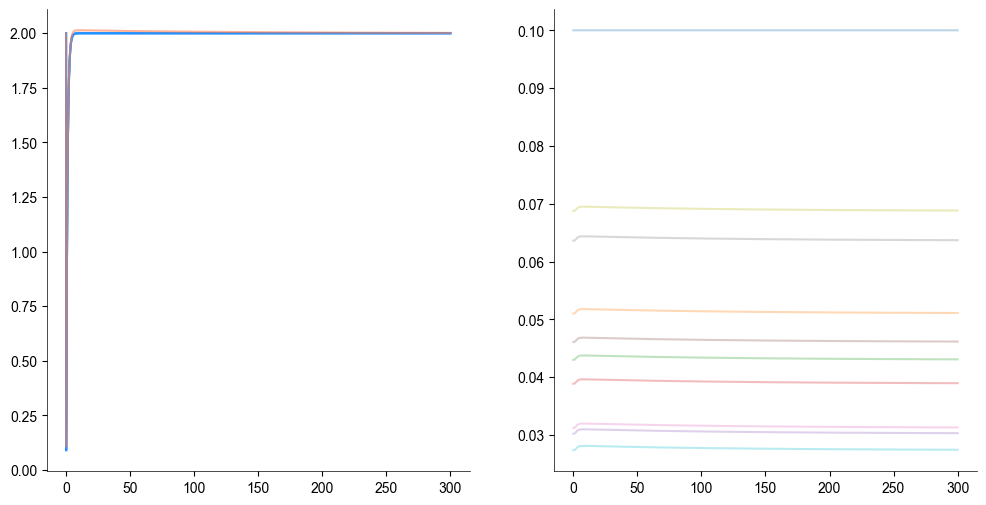

In [31]:
M = networks[0]["M"]
S = networks[0]["S"]

fig, axs = plt.subplots(1,2, figsize=(12,6))

axs[0].plot(M.t, M.r[:-1].T, alpha=0.3, color='dodgerblue', linewidth=1.5)
axs[0].plot(M.t, M.r[-1].T, alpha=0.6, color='coral', linewidth=1.5)
axs[1].plot(S.t, S.w.T, alpha=0.3, linewidth=1.5)

plt.show()

In [32]:
tau_slows = np.array([1])*second

delt_ws_random = zeros((tau_slows.size, w_grid.size))
delt_ws_sync = zeros_like(delt_ws_random)
delt_ws_gameplay = zeros_like(delt_ws_random)
for i, tau_slow in enumerate(tau_slows):
    for j, network in enumerate(networks):
        w_random = random_stimulation(network, tau_slow)
        w_sync = sync_stimulation(network, tau_slow, t_after=0.3*second)
        w_gameplay = gameplay_stimulation(network, tau_slow, t_stim=0.5*second)
        delt_ws_random[i,j] = w_random - network["w_stim"]
        delt_ws_sync[i,j] = w_sync - network["w_stim"]
        delt_ws_gameplay[i,j] = w_gameplay - network["w_stim"]
        
        # w_random = random_stimulation(network, tau_slow)
        # delt_ws_random[i,j] = np.sum(network['S'].dw[0][(network['S'].t >= 300*second) & (network['S'].t <= 316*second)]) * LR * DT_RECORD
        # w_sync = sync_stimulation(network, tau_slow)
        # delt_ws_sync[i,j] = np.sum(network['S'].dw[0][(network['S'].t >= 300*second) & (network['S'].t <= 300.4*second)]) * LR * DT_RECORD

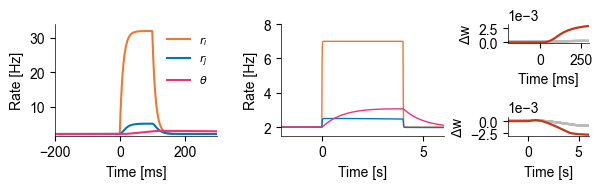

In [41]:
plt.style.use(['nature_d'])

fig, axs = plt.subplot_mosaic([["Reward", "Punishment", "Reward_W"], ["Reward", "Punishment", "Punishment_W"]],
                               width_ratios=[2,2,1])

# Reward
network = networks[0] # 0.1
network["net"].restore("post_sync_1.00")
M = network["M"]
S = network["S"]
axs["Reward"].plot((M.t-300*second)*1_000, M.r[0].T, label=r'$r_i$', linewidth=1.5,color=ORANGE)
axs["Reward"].plot((M.t-300*second)*1_000, M.r[-1].T, label=r'$r_j$', linewidth=1.5,color=DARK_BLUE)
axs["Reward"].plot((S.t-300*second)*1_000, S.theta[0].T, label=r'$\theta$', linewidth=1.5,color=PINK)
axs["Reward"].legend(frameon=True, facecolor="white", framealpha=1.0, edgecolor="white")

axs["Reward_W"].plot((S.t-300*second)*1_000, S.w.T - S.w[:,0], alpha=1, linewidth=1.5, color=GRAY)
axs["Reward_W"].plot((S.t-300*second)*1_000, S.w[0].T - S.w[0,0], alpha=1, linewidth=1.5, color=RED, label=r'$w_{ij}$')

axs["Reward"].set_ylim(1.5, 34)
axs["Reward"].set_xlim(-200, 300)
axs["Reward"].set_xlabel('Time [ms]')

axs["Reward_W"].set_xlabel('Time [ms]')
axs["Reward_W"].set_xlim(-200, 300)


network["net"].restore("post_random_1.00")
M = network["M"]
S = network["S"]
axs["Punishment"].plot(M.t-300*second, M.r[0].T, label=r'$r_i$', color=ORANGE)
axs["Punishment"].plot(M.t-300*second, M.r[-1].T, label=r'$r_i$', color=DARK_BLUE)
axs["Punishment"].plot(S.t-300*second, S.theta[0].T, label=r'$\theta$', color=PINK)

axs["Punishment_W"].plot(S.t-300*second, S.w.T - S.w[:,0], alpha=1, linewidth=1.5, color=GRAY)
axs["Punishment_W"].plot(S.t-300*second, S.w[0].T - S.w[0,0], alpha=1, linewidth=1.5, color=RED)

axs["Punishment"].set_xlim(-2, 6)
axs["Punishment"].set_ylim(1.5, 8)
axs["Punishment"].set_xlabel('Time [s]')

axs["Punishment_W"].set_xlim(-2, 6)
axs["Punishment_W"].set_xlabel('Time [s]')



for ax in [axs["Reward"], axs["Punishment"]]:
    ax.set_ylabel('Rate [Hz]')
    
for ax in [axs["Reward_W"], axs["Punishment_W"]]:
    ax.set_ylabel(r'$\Delta$w')
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    # ax.set_ylim([0, 0.11])
    
w, h = fig.get_size_inches()
fig.set_size_inches(w, 2.)

fig.tight_layout()
if SAVE:
    fig.savefig("fig_4_ExamplesSingeStimsRandP.pdf", dpi=300)
plt.show()

In [34]:
S.w.shape

(10, 309000)

In [35]:
S.w.T - S.w[:,0]

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  3.37817956e-09,  3.37817956e-09, ...,
         3.37817956e-09,  3.37817956e-09,  3.37817956e-09],
       [ 0.00000000e+00,  1.33092840e-08,  1.33092840e-08, ...,
         1.33092840e-08,  1.33092840e-08,  1.33092840e-08],
       ...,
       [-2.82912266e-03, -1.00225532e-03, -1.00225532e-03, ...,
        -1.00225532e-03, -1.00225532e-03, -1.00225532e-03],
       [-2.82911686e-03, -1.00224952e-03, -1.00224952e-03, ...,
        -1.00224952e-03, -1.00224952e-03, -1.00224952e-03],
       [-2.82911105e-03, -1.00224371e-03, -1.00224371e-03, ...,
        -1.00224371e-03, -1.00224371e-03, -1.00224371e-03]],
      shape=(309000, 10))